In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/data-science-bowl-2018/stage1_test.zip
/kaggle/input/competitions/data-science-bowl-2018/stage1_sample_submission.csv.zip
/kaggle/input/competitions/data-science-bowl-2018/stage2_sample_submission_final.csv.zip
/kaggle/input/competitions/data-science-bowl-2018/stage1_train.zip
/kaggle/input/competitions/data-science-bowl-2018/stage1_train_labels.csv.zip
/kaggle/input/competitions/data-science-bowl-2018/stage1_solution.csv.zip
/kaggle/input/competitions/data-science-bowl-2018/stage2_test_final.zip


In [2]:

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import zipfile
import shutil

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 256
BATCH_SIZE = 16
EPOCHS = 20

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
RAW_DIR = "/kaggle/input/competitions/data-science-bowl-2018"

# Separate directories for train and test
TRAIN_DIR = "/kaggle/working/stage1_train"
TEST_DIR = "/kaggle/working/stage1_test"

# Remove previous incomplete extraction, if any
if os.path.exists(TRAIN_DIR):
    shutil.rmtree(TRAIN_DIR)

if os.path.exists(TEST_DIR):
    shutil.rmtree(TEST_DIR)

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

# Extract training data
train_zip = os.path.join(RAW_DIR, "stage1_train.zip")

with zipfile.ZipFile(train_zip, "r") as z:
    z.extractall(TRAIN_DIR)

# Extract test data
test_zip = os.path.join(RAW_DIR, "stage1_test.zip")

with zipfile.ZipFile(test_zip, "r") as z:
    z.extractall(TEST_DIR)

print("Training directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)

print("Training directory exists:", os.path.exists(TRAIN_DIR))
print("Test directory exists:", os.path.exists(TEST_DIR))

print("Number of training samples:",
      len(os.listdir(TRAIN_DIR)))

print("Number of test samples:",
      len(os.listdir(TEST_DIR)))

Training directory: /kaggle/working/stage1_train
Test directory: /kaggle/working/stage1_test
Training directory exists: True
Test directory exists: True
Number of training samples: 670
Number of test samples: 65


In [4]:

def load_sample(image_id, train=True):
    root = TRAIN_DIR if train else TEST_DIR
    image_path = os.path.join(root, image_id, "images", image_id + ".png")

    image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0

    if train:
        mask = np.zeros((h, w), dtype=np.uint8)
        mask_dir = os.path.join(root, image_id, "masks")

        for f in os.listdir(mask_dir):
            m = cv2.imread(os.path.join(mask_dir, f), cv2.IMREAD_GRAYSCALE)
            mask[m > 0] = 1

        mask = cv2.resize(
            mask, (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_NEAREST
        ).astype(np.float32)

        return image, mask

    return image, (h, w)

image_ids = sorted(os.listdir(TRAIN_DIR))
image_ids = [
    x for x in image_ids
    if os.path.isdir(os.path.join(TRAIN_DIR, x))
]

train_ids, val_ids = train_test_split(
    image_ids, test_size=0.2, random_state=SEED
)

print("Training:", len(train_ids))
print("Validation:", len(val_ids))


Training: 536
Validation: 134


In [5]:

def load_dataset(ids):
    X, Y = [], []

    for image_id in tqdm(ids):
        image, mask = load_sample(image_id)
        X.append(image)
        Y.append(mask[..., None])

    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

X_train, Y_train = load_dataset(train_ids)
X_val, Y_val = load_dataset(val_ids)

print("Train:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)


  0%|          | 0/536 [00:00<?, ?it/s]

  0%|          | 0/134 [00:00<?, ?it/s]

Train: (536, 256, 256, 3) (536, 256, 256, 1)
Validation: (134, 256, 256, 3) (134, 256, 256, 1)


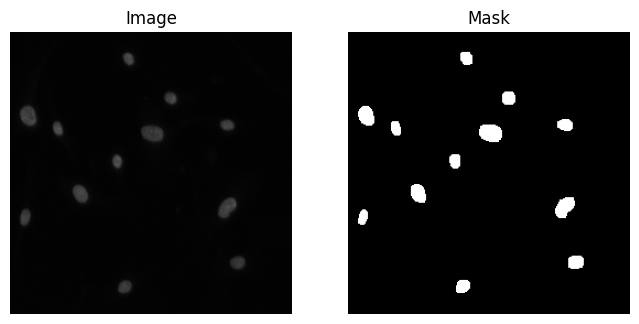

In [6]:

i = 0

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(X_train[i])
plt.axis("off")
plt.title("Image")

plt.subplot(1, 2, 2)
plt.imshow(Y_train[i, ..., 0], cmap="gray")
plt.axis("off")
plt.title("Mask")
plt.show()


In [7]:

def encoder_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    p = tf.keras.layers.MaxPooling2D(2)(x)
    return x, p

def decoder_block(x, skip, filters):
    x = tf.keras.layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = tf.keras.layers.Concatenate()([x, skip])
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x

def unet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = tf.keras.Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    b = tf.keras.layers.Conv2D(1024, 3, padding="same", activation="relu")(p4)
    b = tf.keras.layers.Conv2D(1024, 3, padding="same", activation="relu")(b)

    d1 = decoder_block(b, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    return tf.keras.Model(
        inputs,
        tf.keras.layers.Conv2D(1, 1, activation="sigmoid")(d4)
    )

model = unet()
model.summary()


I0000 00:00:1790171738.868261      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790171738.870958      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:

def dice_loss(y_true, y_pred):
    smooth = 1.0
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true * y_pred)
    dice = (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )
    return 1.0 - dice

def loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

def dice_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.0 * intersection + 1e-6) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1e-6
    )

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=loss,
    metrics=[dice_metric]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_unet.keras",
        monitor="val_dice_metric",
        mode="max",
        save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_metric",
        mode="max",
        patience=4,
        restore_best_weights=True
    )
]


In [9]:

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    shuffle=True
)


Epoch 1/20


2026-09-23 13:56:09.611009: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 13:56:09.840505: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 13:56:18.375544: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 13:56:18.689630: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv (f32[16,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01

33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - dice_metric: 0.1708 - loss: 1.4928

2026-09-23 13:57:40.701663: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 13:57:40.929857: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 13:57:46.165087: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 13:57:46.474124: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv (f32[8,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, 

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_metric: 0.1723 - loss: 1.4904   

2026-09-23 13:58:41.709370: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 13:58:41.935890: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 13:58:43.014614: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 13:58:43.319064: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 13:58:50.777770: E external/local_xla/xla/stream_

34/34 ━━━━━━━━━━━━━━━━━━━━ 194s 3s/step - dice_metric: 0.2217 - loss: 1.4091 - val_dice_metric: 0.2766 - val_loss: 1.1447
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 28s 820ms/step - dice_metric: 0.3346 - loss: 0.9136 - val_dice_metric: 0.2593 - val_loss: 0.7927
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 29s 869ms/step - dice_metric: 0.5509 - loss: 0.8031 - val_dice_metric: 0.6098 - val_loss: 0.9834
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 29s 860ms/step - dice_metric: 0.7109 - loss: 0.6010 - val_dice_metric: 0.6529 - val_loss: 0.6127
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 29s 865ms/step - dice_metric: 0.7388 - loss: 0.5254 - val_dice_metric: 0.7590 - val_loss: 0.4380
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 29s 864ms/step - dice_metric: 0.7969 - loss: 0.4080 - val_dice_metric: 0.7870 - val_loss: 0.3937
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 28s 815ms/step - dice_metric: 0.8261 - loss: 0.3556 - val_dice_metric: 0.7166 - val_loss: 0.4493
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 29s 866ms/step - dice_metric: 

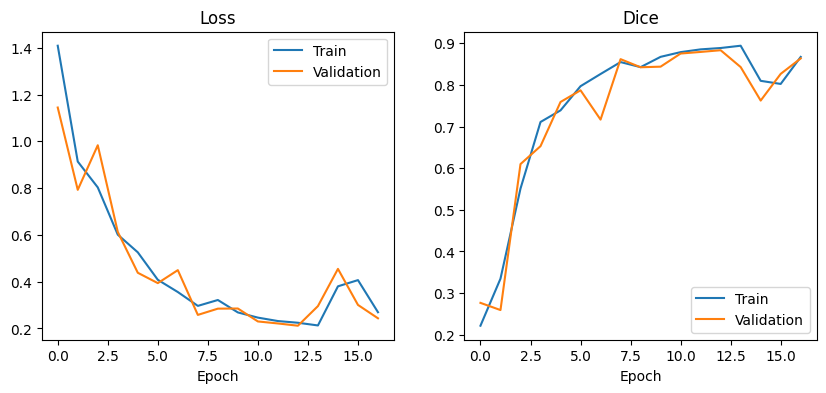

In [10]:

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["dice_metric"], label="Train")
plt.plot(history.history["val_dice_metric"], label="Validation")
plt.title("Dice")
plt.xlabel("Epoch")
plt.legend()

plt.show()


2026-09-23 14:06:33.440685: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 14:06:33.640409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 14:06:34.160152: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 14:06:34.421218: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 14:06:37.336715: E external/local_xla/xla/stream_

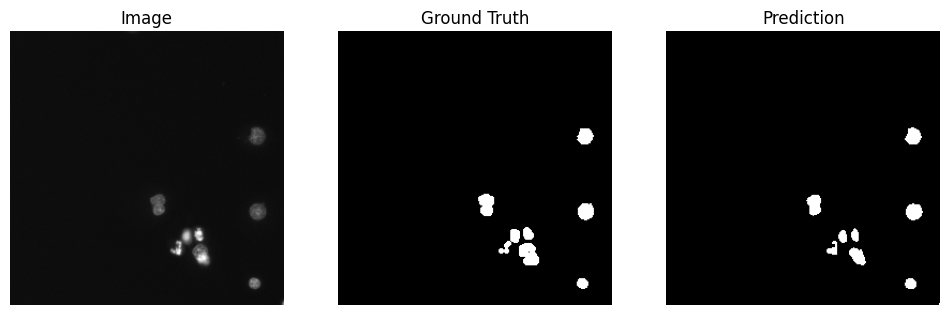

In [11]:

pred = model.predict(X_val[:1], verbose=0)[0, ..., 0] > 0.5

plt.figure(figsize=(12, 4))
for j, (img, title) in enumerate([
    (X_val[0], "Image"),
    (Y_val[0, ..., 0], "Ground Truth"),
    (pred, "Prediction")
]):
    plt.subplot(1, 3, j + 1)
    plt.imshow(img, cmap="gray" if j else None)
    plt.title(title)
    plt.axis("off")
plt.show()


In [12]:

def instance_masks(binary):
    binary = binary.astype(np.uint8)

    # Separate touching nuclei with watershed.
    distance = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    _, foreground = cv2.threshold(
        distance, 0.3 * distance.max(), 255, 0
    )
    foreground = np.uint8(foreground)

    background = cv2.dilate(binary, np.ones((3, 3), np.uint8), iterations=2)
    unknown = cv2.subtract(background, foreground)

    _, markers = cv2.connectedComponents(foreground)
    markers += 1
    markers[unknown == 255] = 0

    image = cv2.cvtColor(binary * 255, cv2.COLOR_GRAY2BGR)
    markers = cv2.watershed(image, markers)

    return [
        (markers == label).astype(np.uint8)
        for label in range(2, markers.max() + 1)
        if np.sum(markers == label) > 20
    ]

def rle_encode(mask):
    pixels = mask.flatten(order="F")
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(map(str, runs))


In [13]:

test_ids = sorted([
    x for x in os.listdir(TEST_DIR)
    if os.path.isdir(os.path.join(TEST_DIR, x))
])

rows = []

for image_id in tqdm(test_ids, desc="Generating submission"):
    image, (h, w) = load_sample(image_id, train=False)

    pred = model.predict(image[None], verbose=0)[0, ..., 0]
    pred = cv2.resize(pred, (w, h))
    masks = instance_masks((pred > 0.5).astype(np.uint8))

    for mask in masks:
        rle = rle_encode(mask)
        if rle:
            rows.append({
                "ImageId": image_id,
                "EncodedPixels": rle
            })

submission = pd.DataFrame(rows, columns=["ImageId", "EncodedPixels"])
submission.to_csv("/kaggle/working/submission.csv", index=False)

print(submission.head())
print("Predicted instances:", len(submission))
print("Saved to /kaggle/working/submission.csv")


Generating submission:   0%|          | 0/65 [00:00<?, ?it/s]

                                             ImageId  \
0  0114f484a16c152baa2d82fdd43740880a762c93f436c8...   
1  0114f484a16c152baa2d82fdd43740880a762c93f436c8...   
2  0114f484a16c152baa2d82fdd43740880a762c93f436c8...   
3  0114f484a16c152baa2d82fdd43740880a762c93f436c8...   
4  0114f484a16c152baa2d82fdd43740880a762c93f436c8...   

                                       EncodedPixels  
0   45618 5 45872 9 46127 10 46383 9 46639 8 46896 5  
1  50793 5 51047 9 51302 10 51556 13 51812 13 520...  
2  11407 1 11660 6 11915 7 12169 9 12424 10 12680...  
3  32145 5 32398 10 32652 13 32907 14 33162 14 33...  
4  51610 4 51864 6 52119 7 52374 8 52629 8 52884 ...  
Predicted instances: 1805
Saved to /kaggle/working/submission.csv
